# 🛠️ 03_feature_engineering

## Secção da metodologia

- CELL 1 — IMPORT LIBRARIES
- CELL 2 — DEFINE PROJECT PATHS
- CELL 3 — LOAD MARKET DATASET
- CELL 4 — CREATE RETURN-BASED FEATURES
- CELL 5 — CREATE TREND FEATURES
- CELL 6 — CREATE MOMENTUM FEATURES
- CELL 7 — CREATE VOLATILITY FEATURES
- CELL 8 — CREATE VOLUME FEATURES
- CELL 9 — CLEAN FEATURE DATASET
- CELL 10 — SAVE FEATURE DATASET

In [1]:
# ============================================================
# CELL 1 — IMPORT LIBRARIES
# ------------------------------------------------------------
# Objective:
# Import the Python libraries required for market feature
# engineering.
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
# ============================================================
# CELL 2 — DEFINE PROJECT PATHS
# ------------------------------------------------------------
# Objective:
# Define the folder structure used to load the raw dataset
# and save the engineered market features.
# ============================================================

project_root = Path.cwd().parent

datasets_dir = project_root / "datasets"
raw_dir = datasets_dir / "raw"
features_dir = datasets_dir / "features"

features_dir.mkdir(parents=True, exist_ok=True)

file_path = raw_dir / "raw_sp500_data.csv"
output_path = features_dir / "market_features.csv"

print("Input dataset:", file_path)
print("Output dataset:", output_path)

Input dataset: c:\Users\anton\0______MASTER_IN_DATA_SCIENCE\1_SEMESTRE\RESEARCH_METHODOLOGIES\RESEARCH_METHODOLOGIES_2\ML_Stocks_LSTM\datasets\raw\raw_sp500_data.csv
Output dataset: c:\Users\anton\0______MASTER_IN_DATA_SCIENCE\1_SEMESTRE\RESEARCH_METHODOLOGIES\RESEARCH_METHODOLOGIES_2\ML_Stocks_LSTM\datasets\features\market_features.csv


In [3]:
# ============================================================
# CELL 3 — LOAD MARKET DATASET
# ------------------------------------------------------------
# Objective:
# Load the raw market dataset generated in Notebook 01.
# ============================================================

df = pd.read_csv(file_path)

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

df.head()

,Date,ticker,Open,High,Low,Close,Volume
0,2000-01-03,^GSPC,1469.250000,1478.000000,1438.359985,1455.219971,931800000
1,2000-01-04,^GSPC,1455.219971,1455.219971,1397.430054,1399.420044,1009000000
2,2000-01-05,^GSPC,1399.420044,1413.270020,1377.680054,1402.109985,1085500000
3,2000-01-06,^GSPC,1402.109985,1411.900024,1392.099976,1403.449951,1092300000
4,2000-01-07,^GSPC,1403.449951,1441.469971,1400.729980,1441.469971,1225200000


In [4]:
# ============================================================
# CELL 4 — CREATE RETURN-BASED FEATURES
# ------------------------------------------------------------
# Objective:
# Create return-based features from closing prices.
# ============================================================

df["simple_return"] = df["Close"].pct_change()
df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))

In [5]:
# ============================================================
# CELL 5 — CREATE TREND FEATURES
# ------------------------------------------------------------
# Objective:
# Create moving-average-based trend indicators.
# ============================================================

df["sma_10"] = df["Close"].rolling(10).mean()
df["sma_20"] = df["Close"].rolling(20).mean()

df["ema_10"] = df["Close"].ewm(span=10, adjust=False).mean()
df["ema_20"] = df["Close"].ewm(span=20, adjust=False).mean()

df["sma_ratio_10"] = df["Close"] / df["sma_10"] - 1
df["sma_ratio_20"] = df["Close"] / df["sma_20"] - 1

df["ema_ratio_10"] = df["Close"] / df["ema_10"] - 1
df["ema_ratio_20"] = df["Close"] / df["ema_20"] - 1

In [6]:
# ============================================================
# CELL 6 — CREATE MOMENTUM FEATURES
# ------------------------------------------------------------
# Objective:
# Create momentum-based indicators.
# ============================================================

df["mom_5"] = df["Close"] / df["Close"].shift(5) - 1
df["mom_10"] = df["Close"] / df["Close"].shift(10) - 1

delta = df["Close"].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss
df["rsi_14"] = 100 - (100 / (1 + rs))

ema_12 = df["Close"].ewm(span=12, adjust=False).mean()
ema_26 = df["Close"].ewm(span=26, adjust=False).mean()

df["macd"] = ema_12 - ema_26
df["macd_signal"] = df["macd"].ewm(span=9, adjust=False).mean()
df["macd_hist"] = df["macd"] - df["macd_signal"]

In [7]:
# ============================================================
# CELL 7 — CREATE VOLATILITY FEATURES
# ------------------------------------------------------------
# Objective:
# Create volatility-based features.
# ============================================================

df["volatility_10"] = df["log_return"].rolling(10).std()
df["volatility_20"] = df["log_return"].rolling(20).std()

df["high_low_range"] = (df["High"] - df["Low"]) / df["Close"]

### Additional Market Dynamics Features

To better capture financial market behavior, two additional feature types are introduced.

First, a **volatility clustering proxy** is computed using the rolling mean of squared log returns. This reflects the well-known stylized fact that periods of high volatility tend to cluster together.

Second, **cumulative momentum features** are calculated over short horizons (5 and 10 days), capturing short-term directional persistence in market movements.

In [8]:
# ============================================================
# CELL 7B — CREATE DRAWDOWN FEATURES
# ------------------------------------------------------------
# Objective:
# Capture market stress by measuring distance from recent
# price peaks. Drawdowns often precede bearish regimes.
# ============================================================

# Rolling peaks
df["rolling_max_10"] = df["Close"].rolling(10).max()
df["rolling_max_20"] = df["Close"].rolling(20).max()

# Drawdown relative to peaks
df["drawdown_10"] = (df["Close"] - df["rolling_max_10"]) / df["rolling_max_10"]
df["drawdown_20"] = (df["Close"] - df["rolling_max_20"]) / df["rolling_max_20"]

# Remove auxiliary columns
df.drop(columns=["rolling_max_10","rolling_max_20"], inplace=True)

In [9]:
# ============================================================
# CELL 7C — ENHANCED DRAWDOWN FEATURES
# ------------------------------------------------------------
# Additional drawdown-based features to capture market stress
# dynamics and regime persistence.
# ============================================================

# Maximum drawdown observed in the last 20 days
df["max_drawdown_20"] = df["drawdown_20"].rolling(20).min()

# Drawdown acceleration (speed of market deterioration)
df["drawdown_change"] = df["drawdown_20"].diff()

# Absolute magnitude of drawdown
df["drawdown_abs"] = df["drawdown_20"].abs()

# Drawdown regime persistence
df["drawdown_persistence"] = (df["drawdown_20"] < -0.02).rolling(10).sum()

# Quick inspection
print("Enhanced drawdown features created:")
print(df[
    [
        "drawdown_20",
        "max_drawdown_20",
        "drawdown_change",
        "drawdown_abs",
        "drawdown_persistence"
    ]
].tail())

Enhanced drawdown features created:
      drawdown_20  max_drawdown_20  drawdown_change  drawdown_abs  \
6606    -0.001139        -0.076538        -0.001139      0.001139   
6607     0.000000        -0.076538         0.001139      0.000000   
6608     0.000000        -0.076538         0.000000      0.000000   
6609     0.000000        -0.076538         0.000000      0.000000   
6610     0.000000        -0.076538         0.000000      0.000000   

      drawdown_persistence  
6606                   7.0  
6607                   6.0  
6608                   5.0  
6609                   4.0  
6610                   3.0  


In [10]:
# ============================================================
# CELL 7B — ADD VOLATILITY CLUSTERING AND CUMULATIVE MOMENTUM
# ------------------------------------------------------------
# Objective:
# Add additional market dynamics features capturing volatility
# clustering and short-term cumulative momentum effects.
# ============================================================

# Volatility clustering proxy (squared returns rolling mean)
df["volatility_20_sq"] = df["log_return"].pow(2).rolling(20).mean()

# Cumulative momentum features
df["ret_5"] = df["log_return"].rolling(5).sum()
df["ret_10"] = df["log_return"].rolling(10).sum()

Additional features are introduced to better capture short-term
market dynamics.

The rolling mean of squared returns approximates volatility
clustering, while cumulative returns over 5 and 10 days capture
short-term momentum in market movements.

In [11]:
# ============================================================
# CELL 8 — CREATE VOLUME FEATURES
# ------------------------------------------------------------
# Objective:
# Create volume-based market activity features.
# ============================================================

df["log_volume"] = np.log1p(df["Volume"])
df["volume_change"] = df["Volume"].pct_change()

df["volume_ma_10"] = df["Volume"].rolling(10).mean()
df["volume_ratio_10"] = df["Volume"] / df["volume_ma_10"]

In [12]:
# ============================================================
# CELL 9 — CLEAN FEATURE DATASET
# ------------------------------------------------------------
# Objective:
# Remove rows with missing values created by rolling windows
# and inspect the final feature dataset.
# ============================================================

df_features = df.dropna().reset_index(drop=True)

print("Feature dataset shape:", df_features.shape)

df_features.head()

Feature dataset shape: (6573, 39)


,Date,ticker,Open,High,Low,Close,Volume,simple_return,log_return,sma_10,...,drawdown_change,drawdown_abs,drawdown_persistence,volatility_20_sq,ret_5,ret_10,log_volume,volume_change,volume_ma_10,volume_ratio_10
0,2000-02-28,^GSPC,1333.359985,1360.819946,1325.069946,1348.050049,1026500000,0.011017,0.010957,1366.171008,...,0.010189,0.064971,10.0,0.000174,0.001455,-0.028571,20.749421,-0.036331,1.039570e+09,0.987427
1,2000-02-29,^GSPC,1348.050049,1369.630005,1348.050049,1366.420044,1204300000,0.013627,0.013535,1363.819019,...,0.012742,0.052229,10.0,0.000152,0.010483,-0.017066,20.909164,0.173210,1.067270e+09,1.128393
2,2000-03-01,^GSPC,1366.420044,1383.459961,1366.420044,1379.189941,1274100000,0.009346,0.009302,1361.533008,...,0.008857,0.043372,10.0,0.000151,0.013504,-0.016439,20.965506,0.057959,1.085470e+09,1.173777
3,2000-03-02,^GSPC,1379.189941,1386.560059,1370.349976,1381.760010,1198600000,0.001863,0.001862,1360.942004,...,0.001783,0.041589,10.0,0.000151,0.020716,-0.004268,20.904420,-0.059258,1.103450e+09,1.086230
4,2000-03-03,^GSPC,1381.760010,1410.880005,1381.760010,1409.170044,1150300000,0.019837,0.019643,1363.033008,...,0.019012,0.022577,10.0,0.000164,0.055299,0.014950,20.863289,-0.040297,1.115000e+09,1.031659


In [13]:
# ============================================================
# CELL 10 — SAVE FEATURE DATASET
# ------------------------------------------------------------
# Objective:
# Save the engineered market feature dataset for use in the
# dataset construction and modelling stages.
# ============================================================

df_features.to_csv(output_path, index=False)

print("Market feature dataset saved to:")
print(output_path)

Market feature dataset saved to:
c:\Users\anton\0______MASTER_IN_DATA_SCIENCE\1_SEMESTRE\RESEARCH_METHODOLOGIES\RESEARCH_METHODOLOGIES_2\ML_Stocks_LSTM\datasets\features\market_features.csv


In [14]:


df_features.shape

(6573, 39)

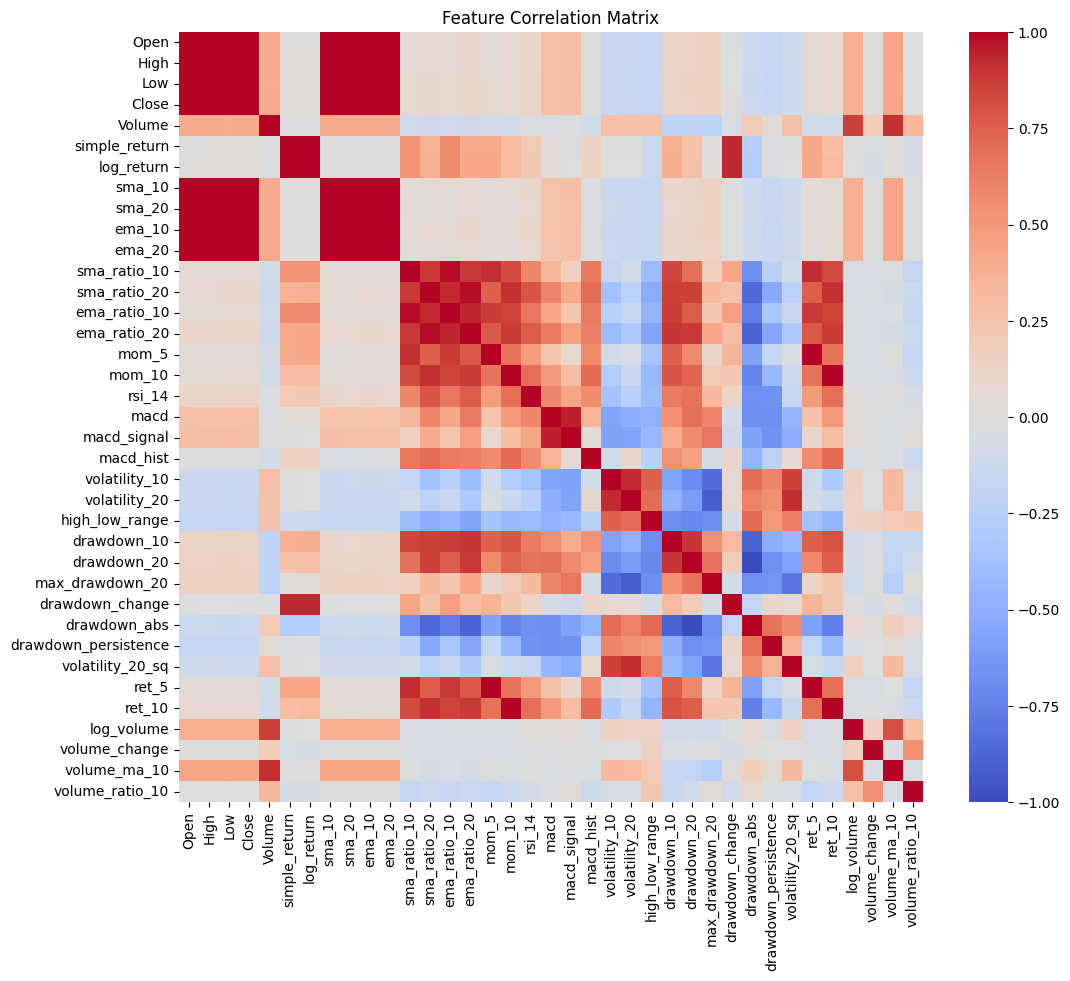

In [15]:
# ============================================================
# FEATURE CORRELATION MATRIX
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt

features = df.drop(columns=["Date","ticker","target"], errors="ignore")

corr = features.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")

plt.show()

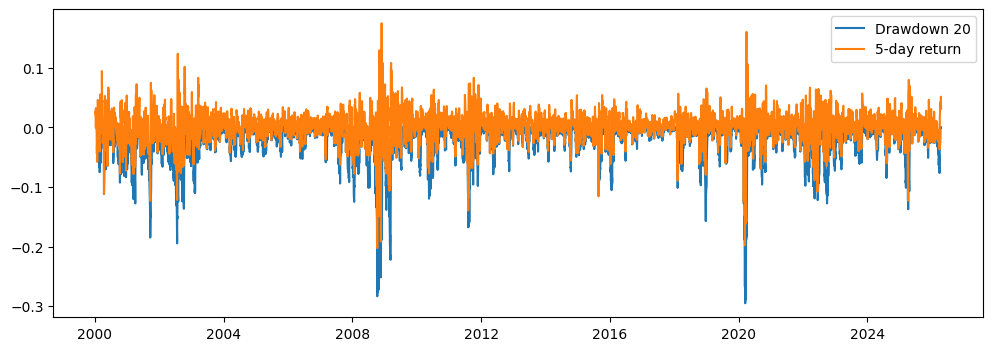

In [16]:
plt.figure(figsize=(12,4))

plt.plot(df["Date"], df["drawdown_20"], label="Drawdown 20")
plt.plot(df["Date"], df["ret_5"], label="5-day return")

plt.legend()
plt.show()